# Neural control of a rod with `dismech-jax`

This notebook reproduces the idea of **Neural Control** (Tong et al., *Adjoint Learning Through Equilibrium Constraints*, arXiv:2605.03288), Task 3 (*shape formation under multistability*), with the existing framework.

A straight elastic strip is clamped at its right end. A small neural network drives the **left clamp** $(p_x, p_y, \phi)$ along a continuation parameter $\tau\in[0,1]$. At every step the strip's free DOFs are the **equilibrium** of the potential energy, $\nabla_x E(x, z)=0$, solved by `System.solve` (warm-started, so the result is path dependent). The network is trained so that the final shape matches a target **curvature profile**

$$\mathcal L(\Theta)=\frac{1}{L}\int_0^L \big(\kappa(s;1)-\kappa^*(s)\big)^2\,ds .$$

**How the framework maps onto the paper**

| Paper | `dismech-jax` |
|---|---|
| boundary DOFs $z=q_b$, free DOFs $x=q_f$ | `System.create(..., fixed=...)`: `sys.idx_z`, `sys.idx_x` |
| equilibrium $G(x,z)=\nabla_xE=0$ | `sys.residual`, solved by `sys.solve` |
| warm-started continuation rollout | `sys.solve(zs, aux)` with `zs` of shape `(K, n_z)` |
| proxy-adjoint gradient (frozen tangent) | **exact** implicit-function-theorem gradient: plain `jax.grad` through `sys.solve` |

Because `solve` already differentiates the whole path-dependent rollout exactly (including the frame updates between steps), no hand-written adjoint is needed.

**Scope.** The paper's headline multistable shapes include an M-like shape. Here we target a stable **two-lobe S-shape** (one curvature sign change) as a first example. The rod is **anisotropic** (stiff out of plane, soft in plane, like a strip), which keeps the deformation planar and makes the in-plane equilibria stable.

In [1]:
import math, time
import equinox as eqx
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from dismech_jax import Geometry, Material, make_rod

jax.config.update("jax_enable_x64", True)

## 1. The strip and its boundary DOFs

Stiffnesses follow the paper: $EA=0.314\,$N, in-plane $EI=7.85\times10^{-8}\,$N·m², no gravity. The out-of-plane bending stiffness is 100× larger (`ixs2`).

DOFs are `[x, y, z, θ]` per node. We clamp the first two nodes (position of node 0, and node 1 which sets the end tangent) and the last two nodes. Those fixed DOFs are `z`; everything else is solved for. Only the left clamp is actuated, through a planar pose $(p_x,p_y,\phi)$: node 0 sits at $(p_x,p_y)$ and node 1 at $(p_x,p_y)+\Delta\ell(\cos\phi,\sin\phi)$.

In [2]:
N, L = 41, 1.0
dl = L / (N - 1)
geom = Geometry(length=L, r0=1e-3, axs=3.14e-6, ixs1=7.85e-13, ixs2=7.85e-11, jxs=1e-10)  # E=1e5 -> EA=0.314, EI1=7.85e-8
mat = Material(density=1200.0, youngs_rod=1e5, poisson_rod=0.3)

left = np.arange(7)  # node 0 (x,y,z,theta) and node 1 (x,y,z)
right = np.array([4 * (N - 2) + i for i in range(4)] + [4 * (N - 1) + i for i in range(3)])
rod, aux0 = make_rod(geom, mat, N=N, fixed=jnp.asarray(np.concatenate([left, right])),
                     gravity=jnp.zeros(3))

# position of each DOF inside the `z` vector
zpos = {int(d): i for i, d in enumerate(np.asarray(rod.idx_z))}

def pose_to_zs(pose):
    # pose: (K, 3) = (px, py, phi) of the left clamp -> fixed DOFs `zs` (K, n_z)
    px, py, phi = pose.T
    zs = jnp.tile(rod.z0, (pose.shape[0], 1))
    zs = zs.at[:, zpos[0]].set(px).at[:, zpos[1]].set(py)
    zs = zs.at[:, zpos[4]].set(px + dl * jnp.cos(phi)).at[:, zpos[5]].set(py + dl * jnp.sin(phi))
    return zs

def curvature(q):
    # signed in-plane discrete curvature at the interior nodes (invariant to rigid motion)
    P = jnp.stack([q[0::4], q[1::4]], 1)
    e = P[1:] - P[:-1]
    a, b = e[:-1], e[1:]
    return jnp.arctan2(a[:, 0] * b[:, 1] - a[:, 1] * b[:, 0], jnp.sum(a * b, 1)) / dl

def final_aux(xs, zs, aux):
    # replay the per-step aux (reference-frame) updates that `solve` performs
    return jax.lax.scan(lambda a, xz: (rod.update(a, *xz), None), aux, (xs, zs))[0]

def min_hessian_eig(xs, zs, aux=aux0):
    # an equilibrium is stable iff the free-DOF Hessian is positive definite
    H, _ = rod.hessian(xs[-1], zs[-1], final_aux(xs, zs, aux))
    return float(jnp.linalg.eigvalsh(H)[0])

## 2. Target shape

We use a known-reachable, **stable** equilibrium as the target: move the left clamp to $(0.6, 0.25)$ while rotating it by $90^\circ$. This is only a teacher used to define $\kappa^*$; the network below never sees this schedule, only the curvature profile. Stability is checked from the Hessian spectrum.

residual 8.6e-15, min Hessian eigenvalue 2.37e-06 (>0 => stable)


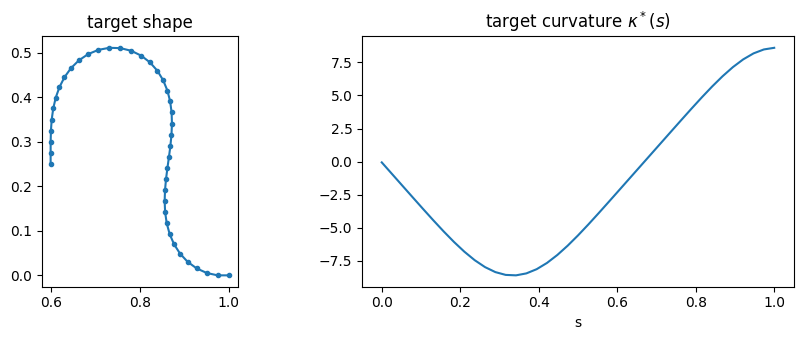

In [3]:
tau = jnp.linspace(0, 1, 200)
teacher = jnp.stack([0.6 * tau, 0.25 * tau, (math.pi / 2) * tau], 1)
zs_t = pose_to_zs(teacher)
xs_t, res_t = rod.solve(zs_t, aux0, iters=25)
q_target = rod.join(xs_t[-1], zs_t[-1])
kappa_target = curvature(q_target)
print(f"residual {float(res_t[-1]):.1e}, min Hessian eigenvalue {min_hessian_eig(xs_t, zs_t):.2e} (>0 => stable)")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].plot(q_target[0::4], q_target[1::4], ".-"); ax[0].set_aspect("equal"); ax[0].set_title("target shape")
ax[1].plot(np.linspace(0, L, N - 2), kappa_target); ax[1].set_title(r"target curvature $\kappa^*(s)$"); ax[1].set_xlabel("s")
plt.tight_layout(); plt.show()

## 3. Neural controller and rollout

The controller is a small MLP $u(\tau)\in\mathbb R^3$ giving the **rates** of $(p_x,p_y,\phi)$ (tanh-bounded), integrated with $K=100$ continuation steps: $\text{pose}_k=\sum_{j\le k}u(\tau_j)/K$. The rollout is a single `sys.solve` over all $K$ steps, so `jax.grad` of the loss w.r.t. the network weights gives the full path-dependent gradient.

The last layer's bias has a small rotation-rate offset: a perfectly straight, compressed strip sits exactly on an unstable symmetric branch, and tilting the clamp breaks that symmetry.

In [4]:
K = 100
taus = jnp.linspace(0, 1, K + 1)[1:]
u_max = jnp.array([1.0, 1.0, 2 * math.pi])

net = eqx.nn.MLP(1, 3, 32, 2, activation=jnp.tanh, key=jax.random.PRNGKey(0))
net = eqx.tree_at(lambda n: n.layers[-1].bias, net, jnp.array([0.0, 0.0, 0.3]))

def rollout(net):
    u = jax.vmap(lambda t: u_max * jnp.tanh(net(t[None])))(taus)   # boundary rates
    pose = jnp.cumsum(u / K, axis=0)                               # z(tau)
    zs = pose_to_zs(pose)
    xs, res = rod.solve(zs, aux0, iters=25)                         # equilibrium at each step
    return pose, xs, zs, res

def loss_fn(net):
    pose, xs, zs, res = rollout(net)
    q = rod.join(xs[-1], zs[-1])
    loss = jnp.mean((curvature(q) - kappa_target) ** 2) / jnp.mean(kappa_target ** 2)
    return loss, (pose, xs, zs, res)

loss_and_grad = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn, has_aux=True))

## 4. Training (Adam, exact gradients through the equilibrium solves)

In [5]:
def adam_step(params, grads, state, lr=1e-2, b1=0.9, b2=0.999):
    m, v, t = state; t += 1
    m = jax.tree.map(lambda a, g: b1 * a + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda a, g: b2 * a + (1 - b2) * g * g, v, grads)
    step = jax.tree.map(lambda a, b: lr * (a / (1 - b1 ** t)) / (jnp.sqrt(b / (1 - b2 ** t)) + 1e-8), m, v)
    return jax.tree.map(lambda p, s: p - s, params, step), (m, v, t)

params, static = eqx.partition(net, eqx.is_inexact_array)
state = (jax.tree.map(jnp.zeros_like, params), jax.tree.map(jnp.zeros_like, params), 0)
history, t0 = [], time.time()
for it in range(300):
    (loss, (pose, xs, zs, res)), grads = loss_and_grad(eqx.combine(params, static))
    params, state = adam_step(params, eqx.filter(grads, eqx.is_inexact_array), state)
    history.append(float(loss))
    if it % 25 == 0:
        print(f"iter {it:3d}  loss {float(loss):.3e}  max Newton residual {float(res.max()):.1e}  ({time.time()-t0:.0f}s)")
net = eqx.combine(params, static)
loss, (pose, xs, zs, res) = loss_fn(net)
print(f"final loss {float(loss):.3e}, final Newton residual {float(res[-1]):.1e}")

iter   0  loss 1.737e+00  max Newton residual 1.6e-04  (7s)


iter  25  loss 5.621e-01  max Newton residual 5.0e-05  (35s)


iter  50  loss 6.061e-01  max Newton residual 4.6e-05  (62s)


iter  75  loss 6.119e-01  max Newton residual 2.5e-05  (89s)


iter 100  loss 7.108e-01  max Newton residual 8.9e-05  (115s)


...

iter 200  loss 5.624e-01  max Newton residual 5.3e-05  (223s)


iter 225  loss 2.341e-01  max Newton residual 4.1e-05  (250s)


iter 250  loss 9.036e-03  max Newton residual 4.0e-04  (279s)


iter 275  loss 2.059e-04  max Newton residual 2.8e-04  (307s)


final loss 8.763e-06, final Newton residual 8.7e-15


## 5. Result

min Hessian eigenvalue at the final state: 2.37e-06 (>0 => stable equilibrium)


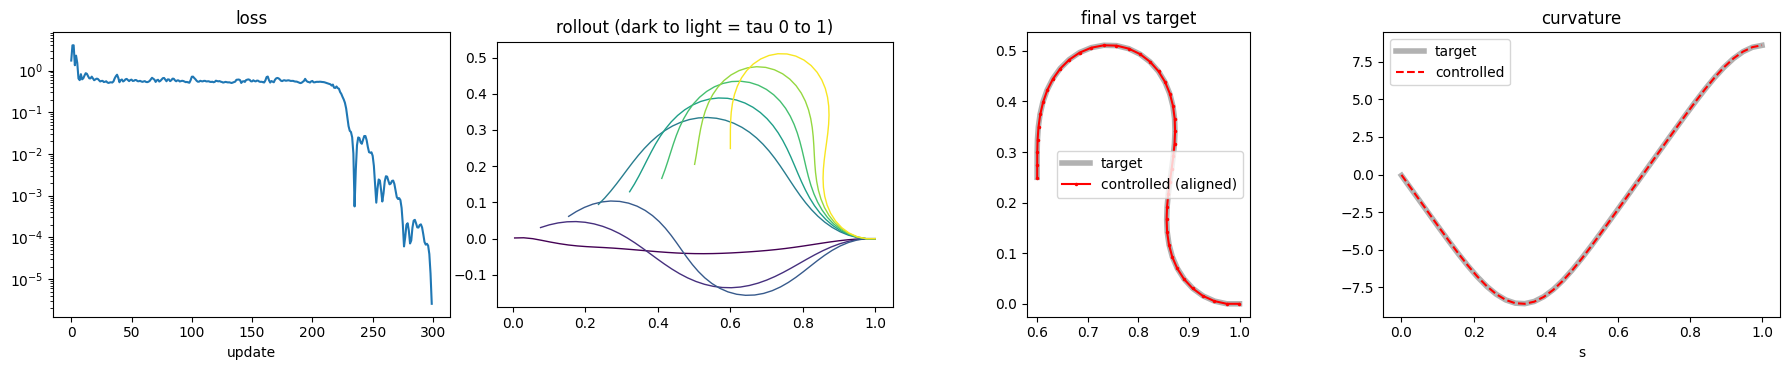

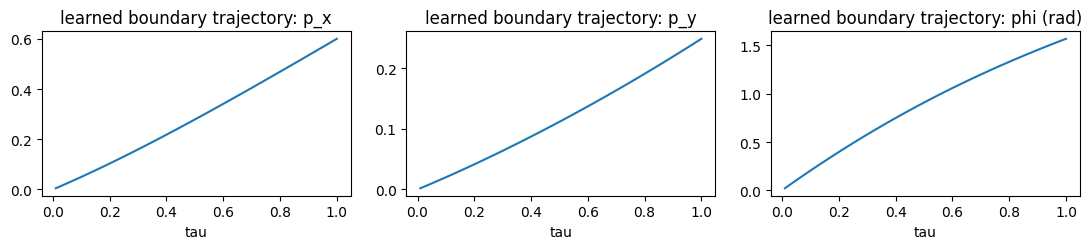

In [6]:
q_final = rod.join(xs[-1], zs[-1])
print(f"min Hessian eigenvalue at the final state: {min_hessian_eig(xs, zs):.2e} (>0 => stable equilibrium)")

fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
ax[0].semilogy(history); ax[0].set_title("loss"); ax[0].set_xlabel("update")

for k in np.linspace(0, K - 1, 8).astype(int):
    q = rod.join(xs[k], zs[k]); ax[1].plot(q[0::4], q[1::4], color=plt.cm.viridis(k / K), lw=1)
ax[1].set_aspect("equal"); ax[1].set_title("rollout (dark to light = tau 0 to 1)")

# the loss is rigid-motion invariant, so align the final shape to the target for display
def align(q, ref):
    P, R = np.stack([q[0::4], q[1::4]], 1), np.stack([ref[0::4], ref[1::4]], 1)
    Pc, Rc = P - P.mean(0), R - R.mean(0)
    U, _, Vt = np.linalg.svd(Pc.T @ Rc)
    return Pc @ (U @ Vt) + R.mean(0)
Pf = align(np.asarray(q_final), np.asarray(q_target))
ax[2].plot(q_target[0::4], q_target[1::4], "k-", lw=4, alpha=.3, label="target")
ax[2].plot(Pf[:, 0], Pf[:, 1], "r.-", ms=3, label="controlled (aligned)")
ax[2].set_aspect("equal"); ax[2].legend(); ax[2].set_title("final vs target")

s = np.linspace(0, L, N - 2)
ax[3].plot(s, kappa_target, "k-", lw=4, alpha=.3, label="target"); ax[3].plot(s, curvature(q_final), "r--", label="controlled")
ax[3].set_title("curvature"); ax[3].set_xlabel("s"); ax[3].legend()
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(11, 2.6))
for i, name in enumerate(["p_x", "p_y", "phi (rad)"]):
    ax[i].plot(np.asarray(taus), np.asarray(pose[:, i])); ax[i].set_title(f"learned boundary trajectory: {name}"); ax[i].set_xlabel("tau")
plt.tight_layout(); plt.show()

## Notes

* **Exact vs proxy gradients.** The paper's adjoint uses a frozen-tangent approximation of the sensitivity $S=\partial x/\partial z$. `System.solve` uses the implicit function theorem *through the whole warm-started sequence*, so `jax.grad` is the exact gradient of the realized rollout; memory is that of the stored states, not of Newton iterations.
* **Multistability / RHC.** The paper's receding-horizon continuation (short segments, controller re-initialised per segment, `(x, z, aux)` carried forward) helps when a run falls into the wrong basin. It can be added on top of this by calling `rod.solve(zs_segment, aux, x0=x_prev)` per segment and updating `aux` with `rod.update`. Here the plain full-horizon rollout already reaches the target branch.
* **Next step.** Swap `kappa_target` for a three-lobe (M) profile once a stable M equilibrium is identified for these boundary conditions.